<a href="https://colab.research.google.com/github/Tanishq7361/Orbital-Motion-and-Euler-Method/blob/main/Orbital_Motion_and_Euler_Method.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gravitational Orbit Simulation using Euler's Method

## Q1. Gravitational Orbit — Equations of Motion

The gravitational potential is:
$$V(r) = -\frac{4\pi^2}{r}$$

This corresponds to a central force (directed toward the origin):
$$\mathbf{F} = -\nabla V = -\frac{4\pi^2}{r^2}\hat{r}$$

In Cartesian coordinates with $r = \sqrt{x^2 + y^2}$, Newton's second law gives:
$$\ddot{x} = -\frac{4\pi^2 x}{r^3}, \qquad \ddot{y} = -\frac{4\pi^2 y}{r^3}$$

We reduce to a first-order system with state vector $(x,\, y,\, v_x,\, v_y)$:
$$\dot{x} = v_x, \quad \dot{y} = v_y, \quad \dot{v}_x = -\frac{4\pi^2 x}{r^3}, \quad \dot{v}_y = -\frac{4\pi^2 y}{r^3}$$

**Units:** astronomical units (AU) for distance and years for time, so that $G M_\odot = 4\pi^2$ AU³/yr² exactly. The Sun sits at the origin.

---

### Energy and Angular Momentum

**Total energy (per unit mass):**
$$E = \frac{1}{2}(v_x^2 + v_y^2) - \frac{4\pi^2}{r}$$

- $E < 0$: bound orbit (ellipse or circle)
- $E = 0$: parabolic escape
- $E > 0$: hyperbolic escape

**Angular momentum (per unit mass):**
$$L = x\, v_y - y\, v_x$$

Both $E$ and $L$ are conserved for the true orbit. Monitoring them tells us how accurate our numerical integration is.

---

### What parameters control the orbit shape?

We start every orbit at $(x_0, y_0) = (1, 0)$ (1 AU from the Sun on the x-axis) and vary the initial velocity $(v_{x0}, v_{y0})$.

- For a **circular orbit** at $r = 1$ AU, the required speed is $v_c = \sqrt{4\pi^2/r} = 2\pi$ AU/yr, directed perpendicular to the radius vector: $(v_x, v_y) = (0, 2\pi)$.
- For an **ellipse**, use a speed different from $v_c$ but still $E < 0$: $(v_x, v_y) = (0, v)$ with $v \ne 2\pi$.
- For a **parabola**, set $E = 0$: $v = \sqrt{2} \cdot 2\pi$.
- For a **hyperbola**, set $E > 0$: $v > \sqrt{2} \cdot 2\pi$.

---

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

GM = 4 * np.pi**2   # gravitational parameter in AU^3/yr^2

def deriv(state):
    x, y, vx, vy = state
    r = np.sqrt(x**2 + y**2)
    ax = -GM * x / r**3
    ay = -GM * y / r**3
    return np.array([vx, vy, ax, ay])

def euler_orbit(state0, dt, n_steps):
    states = np.zeros((n_steps + 1, 4))
    states[0] = state0
    for i in range(n_steps):
        states[i+1] = states[i] + dt * deriv(states[i])
    return states

def energy(state):
    x, y, vx, vy = state.T
    r = np.sqrt(x**2 + y**2)
    return 0.5*(vx**2 + vy**2) - GM/r

def angular_momentum(state):
    x, y, vx, vy = state.T
    return x*vy - y*vx

v_circ = 2 * np.pi   # circular orbit speed at r=1 AU
print(f'Circular orbit speed at 1 AU: v_c = 2π = {v_circ:.4f} AU/yr')

Circular orbit speed at 1 AU: v_c = 2π = 6.2832 AU/yr


## Q1(a): Different Orbit Shapes

Starting position: $(x_0, y_0) = (1, 0)$ AU for all orbits.
Initial velocity: $(v_x, v_y) = (0, v)$ — purely tangential (perpendicular to radius).

| Orbit type | Initial speed $v$ | Reason |
|---|---|---|
| Circle | $v_c = 2\pi$ | Gravity exactly balances centripetal acceleration |
| Ellipse (small) | $0.7\,v_c$ | Speed too low — body falls inward, orbit shrinks |
| Ellipse (large) | $1.3\,v_c$ | Speed too high — body swings out, orbit expands |
| Parabola | $\sqrt{2}\,v_c$ | Exactly escape energy ($E=0$) |
| Hyperbola | $1.6\,v_c$ | Excess energy ($E>0$), escapes to infinity |

---

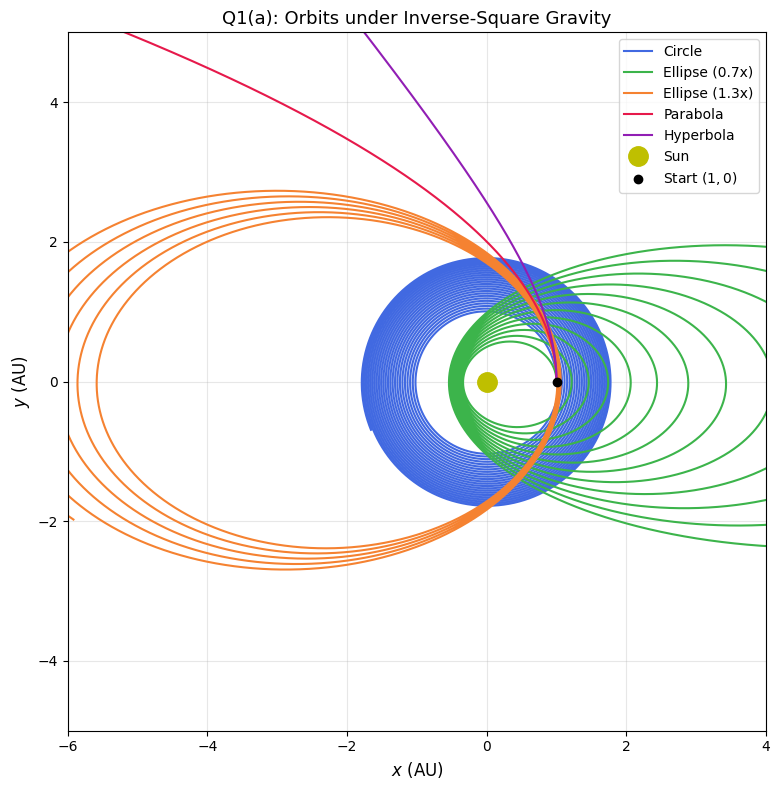

Initial energies:
  Circle                v = 6.2832  E = -19.7392
  Ellipse (0.7x)        v = 4.3982  E = -29.8062
  Ellipse (1.3x)        v = 8.1681  E = -6.1192
  Parabola              v = 8.8858  E = 0.0000
  Hyperbola             v = 10.0531  E = 11.0540


In [ ]:
dt      = 0.0005
n_steps = 80000

orbits = {
    'Circle':        (v_circ,             'royalblue'),
    'Ellipse (0.7x)':(0.7 * v_circ,       '#3cb44b'),
    'Ellipse (1.3x)':(1.3 * v_circ,       '#f58231'),
    'Parabola':      (np.sqrt(2)*v_circ,  '#e6194b'),
    'Hyperbola':     (1.6 * v_circ,       '#911eb4'),
}

fig, ax = plt.subplots(figsize=(8, 8))

for label, (v, color) in orbits.items():
    state0 = np.array([1.0, 0.0, 0.0, v])
    states = euler_orbit(state0, dt, n_steps)
    r = np.sqrt(states[:,0]**2 + states[:,1]**2)
    # stop plotting if body escapes too far
    mask = r < 15
    ax.plot(states[mask, 0], states[mask, 1], color=color, linewidth=1.5, label=label)

ax.plot(0, 0, 'yo', markersize=14, label='Sun', zorder=5)
ax.plot(1, 0, 'ko', markersize=6,  label='Start $(1, 0)$', zorder=5)
ax.set_xlim(-6, 4); ax.set_ylim(-5, 5)
ax.set_aspect('equal')
ax.set_xlabel('$x$ (AU)', fontsize=12)
ax.set_ylabel('$y$ (AU)', fontsize=12)
ax.set_title('Q1(a): Orbits under Inverse-Square Gravity', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Initial energies:')
for label, (v, _) in orbits.items():
    state0 = np.array([[1.0, 0.0, 0.0, v]])
    E0 = energy(state0)[0]
    print(f'  {label:20s}  v = {v:.4f}  E = {E0:.4f}')

### Observations

- **Circle:** closes on itself perfectly (for small enough $dt$). Speed exactly balances gravity at every point.
- **Ellipse ($0.7v_c$):** smaller orbit, perihelion (closest point) on the left, aphelion (farthest point) at the start. Body moves faster near the Sun (Kepler's second law).
- **Ellipse ($1.3v_c$):** larger orbit, aphelion farther from the Sun.
- **Parabola:** open curve, body just barely escapes ($E = 0$). Never returns.
- **Hyperbola:** body escapes quickly with excess energy ($E > 0$).

---

## Q1(a): Step-Size Dependence

We use the **circular orbit** (the most sensitive closed trajectory) and integrate for the same total time with three different step sizes: $dt = 0.01$, $0.001$, $0.0005$.

A perfect integrator would return exactly to the starting point after one period ($T = 1$ year for a 1 AU circular orbit).

---

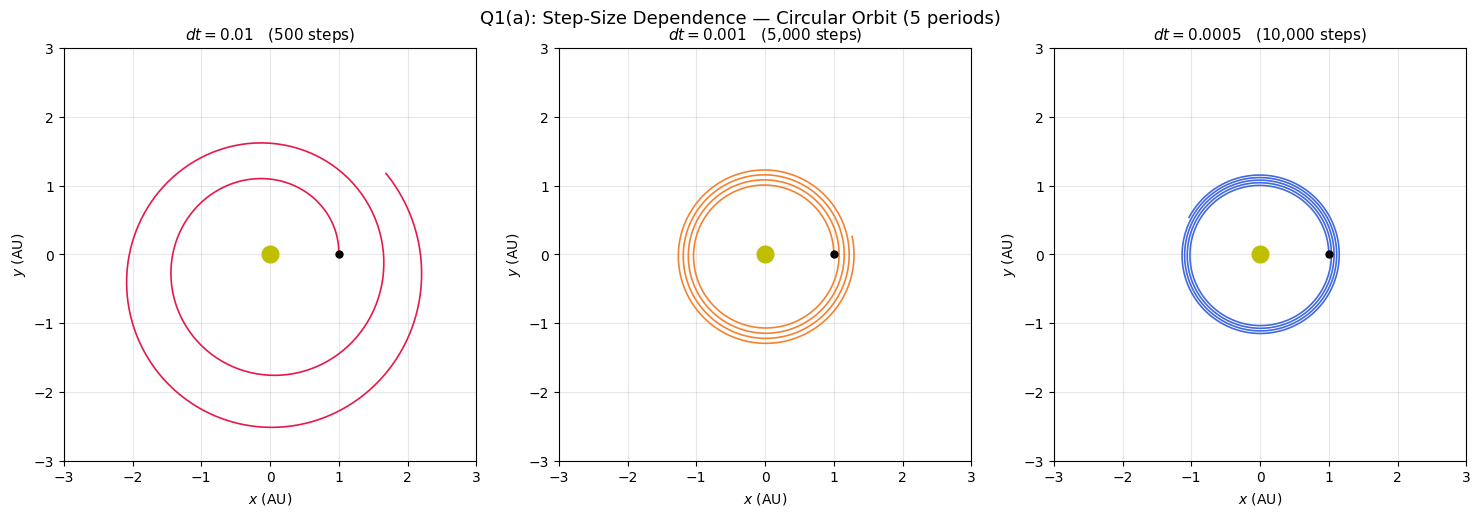

In [ ]:
state0_circ = np.array([1.0, 0.0, 0.0, v_circ])
T_orbit     = 1.0   # one orbital period = 1 year for r=1 AU
n_orbits    = 5     # integrate for 5 complete orbits

step_sizes  = [0.01, 0.001, 0.0005]
colors_dt   = ['#e6194b', '#f58231', 'royalblue']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Q1(a): Step-Size Dependence — Circular Orbit (5 periods)', fontsize=13)

for ax, dt, color in zip(axes, step_sizes, colors_dt):
    n = int(n_orbits * T_orbit / dt)
    states = euler_orbit(state0_circ, dt, n)
    ax.plot(states[:, 0], states[:, 1], color=color, linewidth=1.2)
    ax.plot(0, 0, 'yo', markersize=12, zorder=5)
    ax.plot(1, 0, 'ko', markersize=5, zorder=5)
    ax.set_aspect('equal')
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
    ax.set_xlabel('$x$ (AU)'); ax.set_ylabel('$y$ (AU)')
    ax.set_title(f'$dt = {dt}$   ({n:,} steps)', fontsize=11)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Observations on Step-Size

- **Large $dt = 0.01$:** the orbit visibly spirals **outward** over 5 periods. Euler's method does not conserve energy, and for the gravitational problem it systematically adds energy each step, causing the orbit to expand.
- **Medium $dt = 0.001$:** much less drift, but the spiral is still visible after 5 periods.
- **Small $dt = 0.0005$:** the orbit looks nearly closed. The drift is small but still present — Euler will always spiral outward eventually, no matter how small $dt$ is.

This is a fundamental limitation of Euler's method for Hamiltonian (energy-conserving) systems, so it cannot conserve energy exactly over long times.

---

## Q1(b): Energy at Each Step

For a conservative system, total energy $E = \frac{1}{2}v^2 - \frac{4\pi^2}{r}$ should remain **constant** throughout the orbit. Any change is purely numerical error.

We plot $E(t)$ for the circular orbit at each of the three step sizes.

---

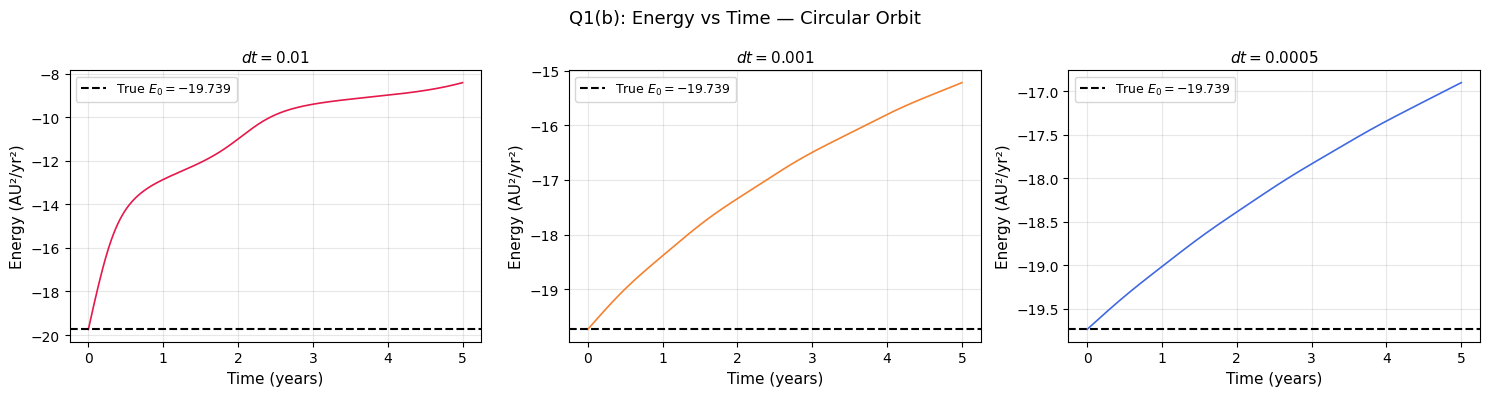

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Q1(b): Energy vs Time — Circular Orbit', fontsize=13)

E0_circ = 0.5 * v_circ**2 - GM   # true initial energy

for ax, dt, color in zip(axes, step_sizes, colors_dt):
    n = int(n_orbits * T_orbit / dt)
    states = euler_orbit(state0_circ, dt, n)
    t = np.linspace(0, n_orbits * T_orbit, n + 1)
    E = energy(states)
    ax.plot(t, E, color=color, linewidth=1.2)
    ax.axhline(y=E0_circ, color='black', linestyle='--', linewidth=1.5, label=f'True $E_0 = {E0_circ:.3f}$')
    ax.set_xlabel('Time (years)', fontsize=11)
    ax.set_ylabel('Energy (AU²/yr²)', fontsize=11)
    ax.set_title(f'$dt = {dt}$', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Energy drift rate: how fast does energy grow?
print('Energy drift over 5 orbits:')
for dt in step_sizes:
    n = int(n_orbits * T_orbit / dt)
    states = euler_orbit(state0_circ, dt, n)
    E = energy(states)
    drift = E[-1] - E[0]
    print(f'  dt = {dt:.4f}  →  ΔE = {drift:+.6f}  ({drift/abs(E[0])*100:.3f}%)')

Energy drift over 5 orbits:
  dt = 0.0100  →  ΔE = +11.321634  (57.356%)
  dt = 0.0010  →  ΔE = +4.523465  (22.916%)
  dt = 0.0005  →  ΔE = +2.838044  (14.378%)


### Observations on Energy

- For all step sizes, the energy **increases monotonically** with time — it never decreases. This is the signature of Euler's method: it is not energy-conserving.
- The rate of energy gain is proportional to $dt$ — halving the step size roughly halves the drift rate, consistent with Euler's $O(h)$ local error.
- The energy oscillates slightly within each orbit (it is not perfectly monotone) — this is because at different points in the orbit the geometry changes. But the **average** always drifts upward.
- Since the total mechanical energy of a bound orbit is negative ($E < 0$), adding positive energy makes $E$ less negative — the orbit gets larger. This explains the outward spiralling seen in Q1(a).

---

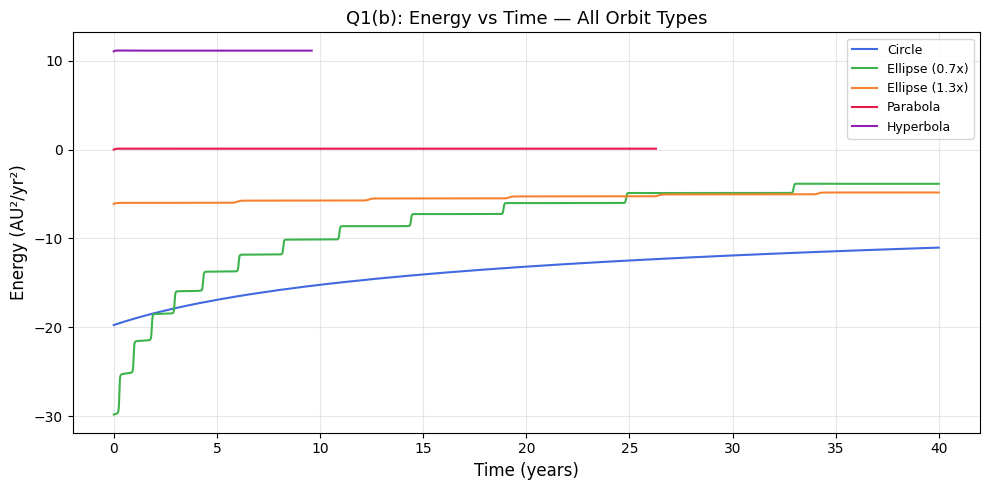

In [ ]:
# Energy plot for all orbit types (single dt = 0.0005)
dt      = 0.0005
n_steps = 80000

fig, ax = plt.subplots(figsize=(10, 5))

for label, (v, color) in orbits.items():
    state0 = np.array([1.0, 0.0, 0.0, v])
    states = euler_orbit(state0, dt, n_steps)
    r = np.sqrt(states[:,0]**2 + states[:,1]**2)
    mask = r < 50
    t = np.arange(np.sum(mask)) * dt
    E = energy(states[mask])
    ax.plot(t, E, color=color, linewidth=1.5, label=label)

ax.set_xlabel('Time (years)', fontsize=12)
ax.set_ylabel('Energy (AU²/yr²)', fontsize=12)
ax.set_title('Q1(b): Energy vs Time — All Orbit Types', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Results Summary

| Orbit | Initial $v$ (AU/yr) | Initial $E$ | Shape |
|---|---|---|---|
| Circle | $2\pi \approx 6.283$ | $-2\pi^2 \approx -19.74$ | Closed circle |
| Ellipse (small) | $0.7 \times 2\pi$ | $< 0$, more negative | Smaller closed ellipse |
| Ellipse (large) | $1.3 \times 2\pi$ | $< 0$, less negative | Larger closed ellipse |
| Parabola | $\sqrt{2} \times 2\pi$ | $\approx 0$ | Open, barely escapes |
| Hyperbola | $1.6 \times 2\pi$ | $> 0$ | Open, escapes with excess speed |

---

## Conclusions

- The shape of the orbit is entirely determined by the **initial speed** relative to the circular orbit speed $v_c = 2\pi$ AU/yr. This follows directly from the total energy $E$.
- Euler's method introduces a systematic **energy drift** — always positive for this problem — causing bound orbits to spiral outward. The drift rate scales with $dt$.
- Even for very small $dt$, Euler cannot maintain a perfectly closed orbit indefinitely. This is because Euler it does not respect the geometric structure (phase space volume conservation) of Hamiltonian systems.
- The energy plot makes this failure explicit: instead of a flat constant line, we see a steadily growing curve whose slope depends on $dt$.